# 📘 Makine Öğrenmesine Giriş — Adım Adım Ders Notu

Bu not defteri, **veri analizi** ve **makine öğrenmesi** konularını sıfırdan öğrenmek isteyenler için hazırlanmıştır.

Kullanılan veri: 21.2 GHz mikrodalga bağlantısına ait hava durumu + sinyal ölçümleri (`data.xlsx`)

### Konular
1. Kütüphaneler ve veri okuma  
2. İlk bakış: head, info, describe  
3. Eksik veriler — nedir, nasıl tamamlanır?  
4. Normalizasyon — neden gerekli?  
5. Kategorik encoding — one-hot nedir?  
6. Basit grafikler  
7. Train / Test Split — neden bölüyoruz?  
8. Model eğitimi (Linear Regression, Random Forest, Gradient Boosting)  
9. GridSearchCV ile hiperparametre arama  
10. Sonuçları okuma: MSE, RMSE, R²


## 1. Kütüphaneleri Yükleme

Python'da her şeyi sıfırdan yazmak zorunda değiliz.  
Başkaları tarafından yazılmış hazır araç setlerine (kütüphane) `import` komutuyla erişiriz.

| Kütüphane | Ne işe yarar? |
|-----------|--------------|
| `pandas` | Tablo (Excel gibi) verileri okur ve işler |
| `numpy` | Sayısal hesaplamalar yapar |
| `matplotlib` | Grafik çizer |
| `seaborn` | Daha güzel grafikler çizer |
| `sklearn` | Makine öğrenmesi modelleri içerir |


In [1]:
# import → "bu kütüphaneyi kullanmak istiyorum" demek
# "as pd" → kütüphaneye kısa takma ad veriyoruz, her seferinde "pandas" yazmak zorunda kalmayız

import pandas as pd          # veri işleme
import numpy as np           # sayısal işlemler
import matplotlib.pyplot as plt  # grafik
import seaborn as sns        # şık grafik

# Grafiklerin boyutu ve stili için genel ayar
plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid")

print("Tüm kütüphaneler başarıyla yüklendi!")


Tüm kütüphaneler başarıyla yüklendi!


## 2. Veriyi Okuma

Excel dosyasını `pd.read_excel()` fonksiyonuyla okuyoruz.  
Dosyada 2 sayfa (sheet) var — biz meteoroloji verisini içeren **Sheet2**'yi kullanıyoruz.


In [2]:
# pd.read_excel() → Excel dosyasını okur, bir DataFrame (tablo) döndürür
# sheet_name → hangi sayfayı okuyacağımızı belirtir
# header=None → başlık satırı otomatik algılanmasın, elle ayarlayacağız

ham_veri = pd.read_excel("data.xlsx", sheet_name="Sheet2", header=None)

# Sheet2'de ilk satır boş, ikinci satır başlık.
# .dropna(how="all") → tamamen boş satırları sil
# .reset_index(drop=True) → satır numaralarını sıfırla (0, 1, 2, ...)
ham_veri = ham_veri.dropna(how="all").reset_index(drop=True)

# İkinci satır (index 0 artık) başlığı içeriyor, geri kalanı veri
df = ham_veri.iloc[1:].copy()          # 2. satırdan itibaren al
df.columns = ham_veri.iloc[0].astype(str).str.strip()   # 1. satırı sütun adı yap
df = df.reset_index(drop=True)        # indeksi tekrar sıfırla

# Sütun adlarını daha kolay yazılır hale getirelim
df = df.rename(columns={
    "History file UTC Time" : "zaman",
    "TEMP (ｰC)"             : "sicaklik",
    "RH (%)"                : "nem",
    "PAINS (HPA)"           : "basinc",
    "1H RAIN (MM)"          : "yagis",
    "WSINS (KT)"            : "ruzgar",
    "RSL"                   : "sinyal",
    "Refrence"              : "sinyal_ref",
    "dB"                    : "zayiflama",
    "dB/km"                 : "zayiflama_km",
    "MOR_1A"                : "gorunurluk",
})

print(f"Veri okundu! Satır: {df.shape[0]}, Sütun: {df.shape[1]}")


Veri okundu! Satır: 39074, Sütun: 11


## 3. İlk Bakış — head, info, describe

Veriyi yükledikten sonra ilk yapacağımız şey **"ne var burada?"** sorusunu sormaktır.  
Bunun için 3 temel komut kullanırız:

| Komut | Ne gösterir? |
|-------|-------------|
| `.head()` | İlk 5 satırı gösterir — verinin genel görünümü |
| `.info()` | Sütun adları, veri tipleri, eksik değer sayısı |
| `.describe()` | Ortalama, min, max, standart sapma gibi istatistikler |


In [3]:
# .head(5) → ilk 5 satırı göster
# Bunu çalıştırarak "veri nasıl görünüyor?" sorusunu yanıtlarız
print("── İLK 5 SATIR ──")
display(df.head(5))


── İLK 5 SATIR ──


,zaman,gorunurluk,sicaklik,nem,basinc,yagis,ruzgar,sinyal,sinyal_ref,zayiflama,zayiflama_km
0,2014-06-01 21:00:00,4400,36.2,23,962.7,0,5.64,-46.1,-43.8,2.3,0.821429
1,2014-06-01 21:01:00,4500,36.1,23,962.7,0,5.25,-46.1,-43.8,2.3,0.821429
2,2014-06-01 21:02:00,4600,36.1,23,962.7,0,4.47,-46.1,-43.8,2.3,0.821429
3,2014-06-01 21:03:00,4600,36.1,23,962.8,0,4.28,-46.1,-43.8,2.3,0.821429
4,2014-06-01 21:04:00,4700,36.1,23,962.8,0,5.25,-46.1,-43.8,2.3,0.821429


In [4]:
# .info() → her sütun hakkında özet bilgi verir:
#   - Sütun adı
#   - Kaç tane dolu (null olmayan) değer var
#   - Veri tipi: object (metin), float64 (ondalıklı sayı), int64 (tam sayı)
#
# Dikkat: Sayısal olması gereken sütunlar "object" görünüyorsa dönüştürmek gerekir!
print("── SÜTUN BİLGİLERİ ──")
df.info()


── SÜTUN BİLGİLERİ ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39074 entries, 0 to 39073
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   zaman         39074 non-null  object
 1   gorunurluk    39074 non-null  object
 2   sicaklik      39074 non-null  object
 3   nem           39074 non-null  object
 4   basinc        39074 non-null  object
 5   yagis         39074 non-null  object
 6   ruzgar        21435 non-null  object
 7   sinyal        39074 non-null  object
 8   sinyal_ref    39074 non-null  object
 9   zayiflama     39074 non-null  object
 10  zayiflama_km  39074 non-null  object
dtypes: object(11)
memory usage: 3.3+ MB


In [5]:
# .describe() → sayısal sütunlar için temel istatistik
#
#   count  → kaç tane dolu değer var
#   mean   → ortalama
#   std    → standart sapma (değerlerin ortalamadan ne kadar saptığı)
#   min    → en küçük değer
#   25%    → değerlerin %25'i bu sayının altında
#   50%    → medyan (ortadaki değer)
#   75%    → değerlerin %75'i bu sayının altında
#   max    → en büyük değer
#
# .T → tabloyu 90 derece döndür (okumak daha kolay olur)
print("── İSTATİSTİKLER ──")
display(df.describe().T)


── İSTATİSTİKLER ──


/tmp/ipykernel_29993/1399452734.py:14: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  display(df.describe().T)


,count,unique,top,freq
0,,,,
zaman,39074,39074,2014-06-01 21:00:00,1
gorunurluk,39074,60,10000,28003
sicaklik,39074.0,197.0,31.6,389.0
nem,39074,70,13,2579
basinc,39074.0,105.0,965.4,881.0
yagis,39074,3,0,39001
ruzgar,21435.0,171.0,5.25,488.0
sinyal,39074.0,41.0,-45.7,3660.0
sinyal_ref,39074.0,1.0,-43.8,39074.0


## 4. Veri Tipi Dönüşümü

Sayılar bazen **metin (object)** olarak gelir — bu durumda hesaplama yapamayız.  
`pd.to_numeric()` ile sayıya çeviririz.

> **errors='coerce'** → sayıya çevrilemeyen değerleri silmek yerine `NaN` (boş) yapar.  
> Bu sayede tek bir hatalı değer tüm sütunu bozmaz.


In [6]:
# Sayısal olması gereken sütunlar
sayisal_sutunlar = ["sicaklik", "nem", "basinc", "yagis", "ruzgar",
                    "sinyal", "sinyal_ref", "zayiflama", "zayiflama_km", "gorunurluk"]

for sutun in sayisal_sutunlar:
    # pd.to_numeric → metni sayıya çevirir
    # errors="coerce" → çevrilemeyen değer varsa NaN yaz (hata verme)
    df[sutun] = pd.to_numeric(df[sutun], errors="coerce")

# Zaman sütununu da datetime formatına çevirelim
df["zaman"] = pd.to_datetime(df["zaman"], errors="coerce")

# Dönüşüm sonrası tiplere bakalım — artık float64 olmalı
print("Dönüşüm sonrası veri tipleri:")
print(df[sayisal_sutunlar].dtypes)


Dönüşüm sonrası veri tipleri:
0
sicaklik        float64
nem             float64
basinc          float64
yagis           float64
ruzgar          float64
sinyal          float64
sinyal_ref      float64
zayiflama       float64
zayiflama_km    float64
gorunurluk      float64
dtype: object


## 5. Eksik Veriler (Missing Values)

Gerçek dünya verisinde bazı değerler **eksik** olabilir — ölçüm cihazının arızalanması,  
veri aktarım hatası gibi sebeplerle.

Python'da eksik değerler **`NaN`** (Not a Number) olarak temsil edilir.

### Neden önemli?
Makine öğrenmesi modelleri genellikle **NaN değerleri işleyemez** — hata verir.  
Bu yüzden eksikleri ya **doldururuz** ya da **sileriz**.

### Doldurma Yöntemleri
| Yöntem | Ne zaman kullanılır? |
|--------|---------------------|
| **Medyan ile doldur** | Aykırı değerler varsa (en güvenli yöntem) |
| **Ortalama ile doldur** | Dağılım normale yakınsa |
| **0 ile doldur** | Eksik = "ölçüm yok" anlamına geliyorsa (ör. yağış) |
| **Önceki değerle doldur** | Zaman serisi verisinde (değer değişmemiştir) |
| **Satırı sil** | Çok az satır eksikse ve silmek veriyi bozmuyorsa |


In [7]:
# Her sütundaki eksik değer sayısı
eksik = df[sayisal_sutunlar].isna().sum()
eksik_yuzde = (eksik / len(df) * 100).round(2)

eksik_tablo = pd.DataFrame({
    "Eksik Sayı"   : eksik,
    "Eksik Yüzde %": eksik_yuzde
})

print("── EKSİK DEĞER RAPORU ──")
display(eksik_tablo[eksik_tablo["Eksik Sayı"] > 0])


── EKSİK DEĞER RAPORU ──


,Eksik Sayı,Eksik Yüzde %
0,,
sicaklik,15,0.04
nem,16,0.04
basinc,14,0.04
yagis,13,0.03
ruzgar,17646,45.16
gorunurluk,26,0.07


In [8]:
# Eksik değerleri dolduralım:

# Yağış → eksik = yağış yok demek, 0 ile doldur
df["yagis"] = df["yagis"].fillna(0)

# Rüzgar → eksik çok fazla (%45+), medyan ile dolduruyoruz
# Medyan: tüm değerleri küçükten büyüğe sıralayınca ortadaki değer
# Ortalamadan farkı: aykırı değerlerden (çok yüksek/düşük) etkilenmez
ruzgar_medyan = df["ruzgar"].median()
df["ruzgar"] = df["ruzgar"].fillna(ruzgar_medyan)
print(f"Rüzgar medyanı: {ruzgar_medyan:.2f} kt → eksikler bu değerle dolduruldu")

# Diğer sayısal sütunlar → medyan ile doldur
for sutun in ["sicaklik", "nem", "basinc", "gorunurluk"]:
    medyan = df[sutun].median()
    df[sutun] = df[sutun].fillna(medyan)

# Kontrol: hâlâ eksik var mı?
kalan_eksik = df[sayisal_sutunlar].isna().sum().sum()
print(f"\nDoldurma sonrası toplam eksik değer: {kalan_eksik}")


Rüzgar medyanı: 6.41 kt → eksikler bu değerle dolduruldu

Doldurma sonrası toplam eksik değer: 0


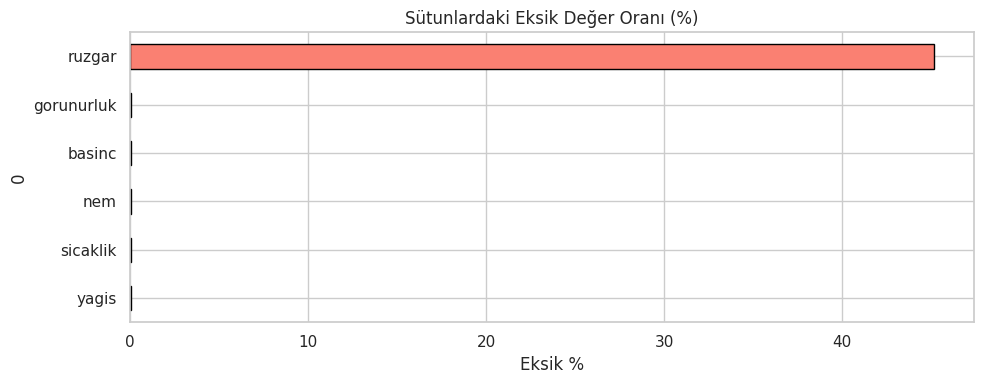

In [9]:
# Eksik değerleri görsel olarak inceleyelim (doldurma öncesi için bilgi amaçlı)
fig, ax = plt.subplots(figsize=(10, 4))

# Yüzde olarak eksik değerleri çubuk grafik ile göster
eksik_yuzde[eksik_yuzde > 0].sort_values().plot(
    kind="barh", ax=ax, color="salmon", edgecolor="black"
)

ax.set_title("Sütunlardaki Eksik Değer Oranı (%)")
ax.set_xlabel("Eksik %")
plt.tight_layout()
plt.show()


## 6. Normalizasyon (Ölçeklendirme)

Farklı sütunlar çok farklı sayı aralıklarında olabilir:
- Sıcaklık: 25 – 45 °C
- Görünürlük: 100 – 10.000 metre
- Rüzgar: 0 – 35 knot

Bazı makine öğrenmesi algoritmaları (özellikle lineer modeller, KNN, SVM)  
**büyük sayılara sahip sütunlara fazla ağırlık verir** — bu adil değildir!

**Normalizasyon** → tüm sütunları aynı ölçeğe getirir.

### İki yaygın yöntem:

| Yöntem | Formül | Sonuç aralığı |
|--------|--------|--------------|
| **Min-Max** | `(x - min) / (max - min)` | 0 ile 1 arası |
| **Standart (Z-Score)** | `(x - ortalama) / std` | Ortalama 0, std 1 |

> **Not:** Karar ağacı tabanlı modeller (Random Forest, GBM) normalizasyona  
> ihtiyaç duymaz — ama Linear Regression için önemlidir.


In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalizasyon için kullanacağımız sütunlar
olcek_sutunlar = ["sicaklik", "nem", "basinc", "yagis", "ruzgar", "gorunurluk"]

# ── Min-Max Normalizasyon ──────────────────────────────────────────────────
# Her değeri 0-1 aralığına sıkıştırır
# fit_transform → önce min/max değerleri öğren (fit), sonra uygula (transform)
min_max = MinMaxScaler()
minmax_sonuc = min_max.fit_transform(df[olcek_sutunlar])

# Sonuçları DataFrame'e çevirelim (sadece görmek için)
minmax_df = pd.DataFrame(minmax_sonuc, columns=[s + "_minmax" for s in olcek_sutunlar])
print("Min-Max sonrası (ilk 3 satır):")
display(minmax_df.head(3))
print(f"Değer aralığı: {minmax_sonuc.min():.2f} – {minmax_sonuc.max():.2f}")

# ── Standart (Z-Score) Normalizasyon ─────────────────────────────────────
# Ortalamayı 0, standart sapmayı 1 yapar
standart = StandardScaler()
standart_sonuc = standart.fit_transform(df[olcek_sutunlar])
print(f"\nZ-Score sonrası ortalama: {standart_sonuc.mean():.4f} (≈0 olmalı)")
print(f"Z-Score sonrası std      : {standart_sonuc.std():.4f}  (≈1 olmalı)")


Min-Max sonrası (ilk 3 satır):


,sicaklik_minmax,nem_minmax,basinc_minmax,yagis_minmax,ruzgar_minmax,gorunurluk_minmax
0,0.566327,0.25,0.407767,0.0,0.158561,0.434343
1,0.561224,0.25,0.407767,0.0,0.147596,0.444444
2,0.561224,0.25,0.407767,0.0,0.125668,0.454545


Değer aralığı: 0.00 – 1.00

Z-Score sonrası ortalama: -0.0000 (≈0 olmalı)
Z-Score sonrası std      : 1.0000  (≈1 olmalı)


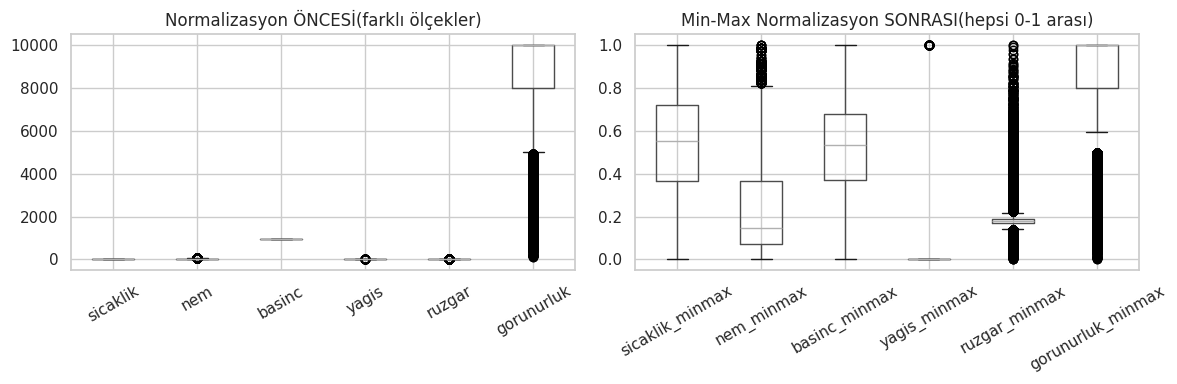

In [12]:
# Normalizasyon öncesi ve sonrasını görsel karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Önce: ham değerler — ölçekler çok farklı
df[olcek_sutunlar].boxplot(ax=axes[0])
axes[0].set_title("Normalizasyon ÖNCESİ(farklı ölçekler)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Sonra: Min-Max normalizasyon — hepsi 0-1 arası
minmax_df.boxplot(ax=axes[1])
axes[1].set_title("Min-Max Normalizasyon SONRASI(hepsi 0-1 arası)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()


## 7. Kategorik Encoding — One-Hot Nedir?

Makine öğrenmesi modelleri **sadece sayılarla** çalışır.  
"sabah", "öğle", "akşam" gibi metin değerleri doğrudan kullanılamaz.

**Çözüm:** Metni sayıya çevirmek → buna **encoding** diyoruz.

### One-Hot Encoding Nedir?
Her kategori için ayrı bir sütun oluşturur ve sadece o kategoriye ait satıra **1**, diğerlerine **0** yazar.

Örnek:

| Zaman Dilimi | gece | sabah | öğle | akşam |
|-------------|------|-------|------|-------|
| sabah       | 0    | **1** | 0    | 0     |
| akşam       | 0    | 0     | 0    | **1** |
| gece        | **1**| 0     | 0    | 0     |

> Bu yöntemi kullanınca model kategoriler arasında **yanlış bir sıra ilişkisi** kurmaz.  
> (ör. "akşam" = 3 demek "akşam, geceden 3 kat daha fazla" anlamına gelmemeli)


In [13]:
# Önce gün içi dilim sütunu oluşturalım
def gun_dilimi(saat):
    if 0 <= saat < 6:
        return "gece"
    elif 6 <= saat < 12:
        return "sabah"
    elif 12 <= saat < 18:
        return "ogle"
    else:
        return "aksam"

# Zaman sütununun saat kısmını çıkar, gun_dilimi fonksiyonunu uygula
df["saat"]       = df["zaman"].dt.hour
df["gun_dilimi"] = df["saat"].apply(gun_dilimi)

print("Gün dilimi dağılımı:")
print(df["gun_dilimi"].value_counts())


Gün dilimi dağılımı:
gun_dilimi
gece     10080
aksam     9900
sabah     9734
ogle      9360
Name: count, dtype: int64


In [14]:
# pd.get_dummies() → one-hot encoding yapar
# prefix="dilim" → yeni sütun adlarının önüne "dilim_" ekler
# dtype=int → True/False yerine 1/0 yazar (daha temiz görünür)

dummies = pd.get_dummies(df["gun_dilimi"], prefix="dilim", dtype=int)
df = pd.concat([df, dummies], axis=1)  # Orijinal tabloya ekle

print("One-Hot Encoding sonucu (ilk 5 satır):")
display(df[["gun_dilimi", "dilim_aksam", "dilim_gece", "dilim_ogle", "dilim_sabah"]].head(5))


One-Hot Encoding sonucu (ilk 5 satır):


,gun_dilimi,dilim_aksam,dilim_gece,dilim_ogle,dilim_sabah
0,aksam,1,0,0,0
1,aksam,1,0,0,0
2,aksam,1,0,0,0
3,aksam,1,0,0,0
4,aksam,1,0,0,0


In [15]:
# Yağış olayı: sayısal bir binary (0/1) değişken
# RAIN_mm > 0 ise yağış var → 1, yoksa → 0
# Bu tür değişkene "binary encoding" denir (sadece 2 kategori)
df["yagis_var"] = (df["yagis"] > 0).astype(int)

print(f"Yağışsız kayıt: {(df['yagis_var'] == 0).sum()}")
print(f"Yağışlı kayıt : {(df['yagis_var'] == 1).sum()}")


Yağışsız kayıt: 39014
Yağışlı kayıt : 60


## 8. Basit Grafikler

Veriye bakmadan model kurmak kör uçuş yapmak gibidir.  
Grafikler bize şunları gösterir:
- Değerler ne aralıkta dağılmış?
- Sıradışı (aykırı) değerler var mı?
- İki değişken arasında ilişki var mı?


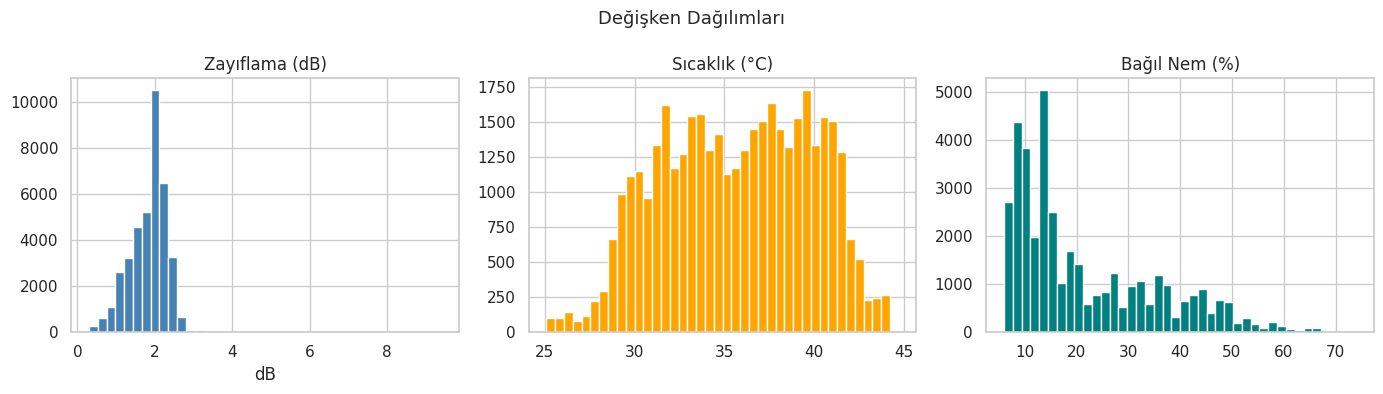

In [16]:
# ── 1. Histogram: Değerlerin dağılımı ────────────────────────────────────────
# bins → kaç çubuğa bölüneceği
# Çan eğrisi gibi → normal dağılım
# Sola/sağa çarpık → bazı modeller için sorun olabilir

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Değişken Dağılımları", fontsize=13)

df["zayiflama"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Zayıflama (dB)")
axes[0].set_xlabel("dB")

df["sicaklik"].hist(bins=40, ax=axes[1], color="orange", edgecolor="white")
axes[1].set_title("Sıcaklık (°C)")

df["nem"].hist(bins=40, ax=axes[2], color="teal", edgecolor="white")
axes[2].set_title("Bağıl Nem (%)")

plt.tight_layout()
plt.show()


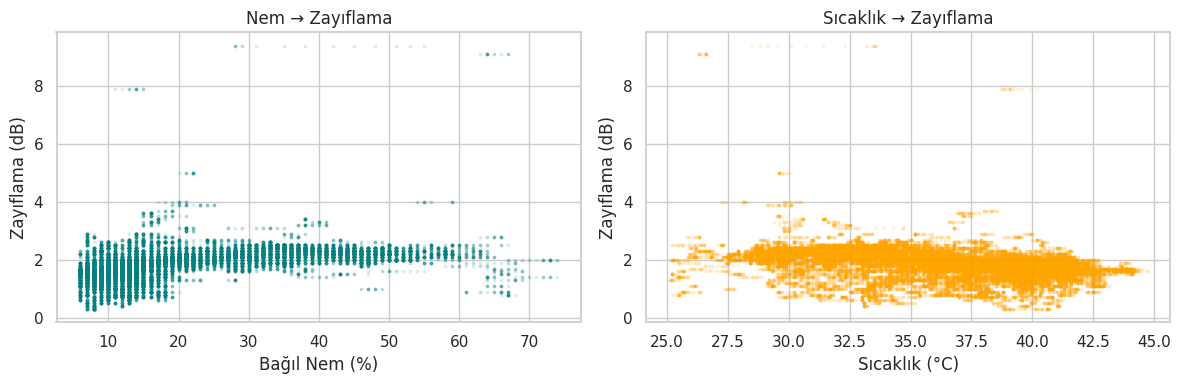

In [17]:
# ── 2. Scatter Plot: İki değişken arasındaki ilişki ──────────────────────────
# alpha → noktaların şeffaflığı (çok nokta üst üste gelirse görmek için)
# s → nokta büyüklüğü

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nem ile zayıflama — ilişki var mı?
axes[0].scatter(df["nem"], df["zayiflama"], alpha=0.1, s=3, color="teal")
axes[0].set_xlabel("Bağıl Nem (%)")
axes[0].set_ylabel("Zayıflama (dB)")
axes[0].set_title("Nem → Zayıflama")

# Sıcaklık ile zayıflama
axes[1].scatter(df["sicaklik"], df["zayiflama"], alpha=0.1, s=3, color="orange")
axes[1].set_xlabel("Sıcaklık (°C)")
axes[1].set_ylabel("Zayıflama (dB)")
axes[1].set_title("Sıcaklık → Zayıflama")

plt.tight_layout()
plt.show()


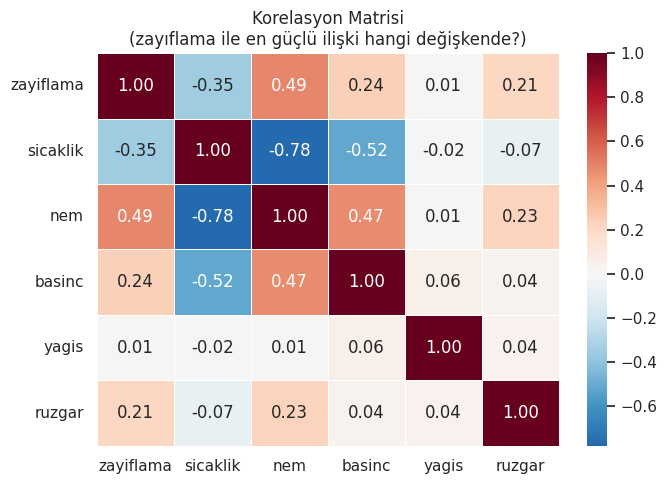

In [18]:
# ── 3. Korelasyon Isı Haritası ────────────────────────────────────────────────
# Korelasyon: iki değişken birlikte nasıl hareket ediyor?
#   +1 → biri artınca diğeri de artar
#   -1 → biri artınca diğeri azalır
#    0 → aralarında ilişki yok

korelasyon_sutunlar = ["zayiflama", "sicaklik", "nem", "basinc", "yagis", "ruzgar"]
korelasyon = df[korelasyon_sutunlar].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    korelasyon,
    annot=True,      # Her hücreye sayıyı yaz
    fmt=".2f",       # 2 ondalık basamak
    cmap="RdBu_r",   # Kırmızı = negatif, Mavi = pozitif
    center=0,
    linewidths=0.5
)
plt.title("Korelasyon Matrisi\n(zayıflama ile en güçlü ilişki hangi değişkende?)")
plt.tight_layout()
plt.show()


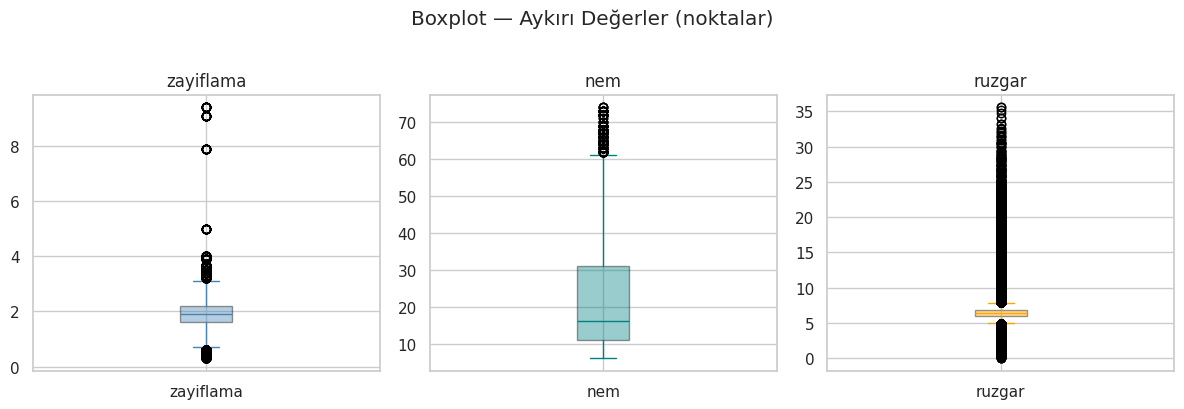

In [19]:
# ── 4. Boxplot: Aykırı değerleri görmek ──────────────────────────────────────
# Kutu → değerlerin %25-%75 aralığı (IQR)
# Orta çizgi → medyan
# Bıyıklar → normal aralık
# Noktalar → AYKIRI DEĞERLER

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, sutun, renk in zip(axes,
                            ["zayiflama", "nem",    "ruzgar"],
                            ["steelblue", "teal", "orange"]):
    df[sutun].plot(kind="box", ax=ax, color=renk, patch_artist=True,
                   boxprops=dict(facecolor=renk, alpha=0.4))
    ax.set_title(sutun)

plt.suptitle("Boxplot — Aykırı Değerler (noktalar)", y=1.02)
plt.tight_layout()
plt.show()


## 9. Train / Test Split — Neden Veriyi Bölüyoruz?

Modeli **tüm veri ile** eğitip yine **tüm veri üzerinde** test edersek aldatmış oluruz.  
Model zaten gördüğü veride iyi sonuç verir — ama yeni gelecek veriyi bilemeyiz.

**Çözüm:** Veriyi **eğitim (train)** ve **test** olarak ikiye böl.

```
Tüm veri
├── %80 → Eğitim seti  (modelin öğrendiği veri)
└── %20 → Test seti    (modelin hiç görmediği veri — gerçek sınav)
```

> `random_state=42` → her çalıştırmada aynı bölünme olsun (tekrarlanabilirlik için)

### X ve y nedir?
- **X** → özellikler (girdi): sıcaklık, nem, yağış, rüzgar...
- **y** → hedef (çıktı, tahmin edilmek istenen): zayıflama (dB)


In [20]:
from sklearn.model_selection import train_test_split

# X → modele vereceğimiz özellikler (bağımsız değişkenler)
# y → tahmin etmek istediğimiz değer (bağımlı değişken = hedef)

ozellikler = ["sicaklik", "nem", "basinc", "yagis", "ruzgar",
              "gorunurluk", "yagis_var", "saat",
              "dilim_aksam", "dilim_gece", "dilim_ogle", "dilim_sabah"]
hedef = "zayiflama"

X = df[ozellikler]
y = df[hedef]

# Hedefte NaN varsa o satırları temizle
gecerli = y.notna()
X = X[gecerli]
y = y[gecerli]

# Eğitim/test bölme
# test_size=0.2 → %20'si test, %80'i eğitim
# random_state=42 → her çalıştırmada aynı bölünme (tekrarlanabilirlik)
X_egitim, X_test, y_egitim, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Toplam veri   : {len(X)} satır")
print(f"Eğitim seti   : {len(X_egitim)} satır (%80)")
print(f"Test seti     : {len(X_test)} satır (%20)")
print(f"\nX sütunları   : {list(X.columns)}")
print(f"y (hedef)     : {hedef}")


Toplam veri   : 39074 satır
Eğitim seti   : 31259 satır (%80)
Test seti     : 7815 satır (%20)

X sütunları   : ['sicaklik', 'nem', 'basinc', 'yagis', 'ruzgar', 'gorunurluk', 'yagis_var', 'saat', 'dilim_aksam', 'dilim_gece', 'dilim_ogle', 'dilim_sabah']
y (hedef)     : zayiflama


In [21]:
# Eksik değerleri dolduracak imputer (özellikle rüzgar sütunu için)
# Pipeline kullanmadan doğrudan uygulayalım:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")  # NaN → medyan ile doldur

# fit → eğitim setinden medyan değerleri öğren
# transform → hem eğitim hem test setine uygula
# ÖNEMLİ: fit() sadece eğitim setine yapılır — test setinin bilgisi sızmaz!
X_egitim = pd.DataFrame(imputer.fit_transform(X_egitim), columns=ozellikler)
X_test   = pd.DataFrame(imputer.transform(X_test),       columns=ozellikler)

print("Eksik değerler dolduruldu.")
print(f"X_egitim NaN sayısı: {X_egitim.isna().sum().sum()}")
print(f"X_test   NaN sayısı: {X_test.isna().sum().sum()}")


Eksik değerler dolduruldu.
X_egitim NaN sayısı: 0
X_test   NaN sayısı: 0


## 10. Model Eğitimi (Varsayılan Parametreler)

Üç farklı algoritma kullanacağız:

### 1. Linear Regression (Doğrusal Regresyon)
En basit model. Değişkenler arasında düz bir doğru ilişkisi olduğunu varsayar.  
`y = a₁x₁ + a₂x₂ + ... + b`

### 2. Random Forest (Rastgele Orman)
Yüzlerce karar ağacı oluşturur, hepsinin tahminini ortalar.  
"Çok kişi fikir yürütürse yanılma payı azalır" mantığı.

### 3. Gradient Boosting
Ağaçları **sırayla** ekler — her yeni ağaç öncekinin hatasını düzeltir.  
Genellikle en yüksek doğruluğu verir, ama daha yavaştır.

---

### Performans Metrikleri

| Metrik | Açıklama | İyi değer |
|--------|----------|-----------|
| **MSE** | Hata karelerinin ortalaması (büyük hatalara ceza) | Küçük olmalı |
| **RMSE** | MSE'nin karekökü — hedefle aynı birimde (dB) | Küçük olmalı |
| **R²** | Modelin varyansı ne kadar açıkladığı (0–1) | 1'e yakın olmalı |


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Üç modeli listede saklıyoruz
modeller = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

sonuclar = []   # Sonuçları buraya biriktireceğiz

for isim, model in modeller.items():
    # 1. Modeli eğit (fit) — sadece eğitim verisiyle!
    model.fit(X_egitim, y_egitim)

    # 2. Test seti için tahmin yap (predict)
    tahmin = model.predict(X_test)

    # 3. Metrikleri hesapla
    mse  = mean_squared_error(y_test, tahmin)
    rmse = mse ** 0.5          # Karekök al → dB cinsinden hata
    r2   = r2_score(y_test, tahmin)

    sonuclar.append({"Model": isim, "MSE": mse, "RMSE": rmse, "R²": r2})
    print(f"{isim:<22}  RMSE={rmse:.4f} dB   R²={r2:.4f}")

print("\nTablo:")
display(pd.DataFrame(sonuclar).set_index("Model"))


Linear Regression       RMSE=0.4115 dB   R²=0.3104
Random Forest           RMSE=0.1688 dB   R²=0.8840
Gradient Boosting       RMSE=0.3438 dB   R²=0.5186

Tablo:


,MSE,RMSE,R²
Model,,,
Linear Regression,0.169355,0.411528,0.310408
Random Forest,0.028498,0.168813,0.883960
Gradient Boosting,0.118229,0.343845,0.518586


## 11. GridSearchCV — Hiperparametre Arama

Modellerin **hiperparametresi** vardır — bunlar eğitimden önce belirlenen ayarlardır.

Örnek:
- Random Forest'ta **kaç ağaç** kullanılacak? (`n_estimators`)
- Ağaçlar **ne kadar derin** olabilir? (`max_depth`)

Bunları elle denemek yerine, `GridSearchCV` **tüm kombinasyonları otomatik dener**  
ve en iyi sonucu veren parametreleri bulur.

### Cross-Validation (CV) Nedir?
`cv=5` → veriyi 5 eşit parçaya böler:
- 4 parça eğitim, 1 parça validasyon → 5 kez tekrar eder
- Her seferinde farklı parça validasyon olur
- 5 skorun ortalaması alınır → daha güvenilir değerlendirme

```
Parça 1: [VAL] [TRN] [TRN] [TRN] [TRN]  → skor 1
Parça 2: [TRN] [VAL] [TRN] [TRN] [TRN]  → skor 2
...
Ortalama skor → bu parametre kombinasyonu için nihai skor
```


In [23]:
from sklearn.model_selection import GridSearchCV

# ── Random Forest için GridSearch ─────────────────────────────────────────────
# Denenecek parametre kombinasyonları
rf_parametreler = {
    "n_estimators" : [50, 100, 200],    # Kaç ağaç? (fazla = iyi ama yavaş)
    "max_depth"    : [None, 10, 20],    # Ağaç derinliği (None = sınırsız)
}

# GridSearchCV:
#   estimator → hangi model
#   param_grid → denenecek parametreler
#   cv=5 → 5-fold cross validation
#   scoring → hangi metriğe göre değerlendirilecek
#   n_jobs=-1 → tüm CPU çekirdeklerini kullan (hızlı)
rf_grid = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = rf_parametreler,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1
)

# .fit() → tüm kombinasyonları dener, en iyisini seçer
rf_grid.fit(X_egitim, y_egitim)

print(f"En iyi parametreler : {rf_grid.best_params_}")
print(f"En iyi CV R² skoru  : {rf_grid.best_score_:.4f}")


En iyi parametreler : {'max_depth': 20, 'n_estimators': 200}
En iyi CV R² skoru  : 0.8769


In [24]:
# ── Gradient Boosting için GridSearch ─────────────────────────────────────────
gbm_parametreler = {
    "n_estimators"  : [100, 200],
    "learning_rate" : [0.05, 0.1],   # Küçük = yavaş öğrenir ama daha stabil
    "max_depth"     : [3, 5],        # Derin ağaç = karmaşık model
}

gbm_grid = GridSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_grid = gbm_parametreler,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1
)

gbm_grid.fit(X_egitim, y_egitim)

print(f"En iyi parametreler : {gbm_grid.best_params_}")
print(f"En iyi CV R² skoru  : {gbm_grid.best_score_:.4f}")


En iyi parametreler : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
En iyi CV R² skoru  : 0.7701


In [25]:
# ── Tüm modelleri karşılaştır ─────────────────────────────────────────────────
# GridSearch'ün bulduğu en iyi modeller vs varsayılan modeller

karsilastirma = []

# Varsayılan modeller (önceden eğitilmişti)
for isim, model in modeller.items():
    tahmin = model.predict(X_test)
    mse    = mean_squared_error(y_test, tahmin)
    karsilastirma.append({
        "Model"  : isim,
        "Yöntem" : "Varsayılan",
        "RMSE"   : round(mse**0.5, 4),
        "R²"     : round(r2_score(y_test, tahmin), 4),
    })

# GridSearch modelleri
for isim, grid in [("Random Forest", rf_grid), ("Gradient Boosting", gbm_grid)]:
    tahmin = grid.predict(X_test)
    mse    = mean_squared_error(y_test, tahmin)
    karsilastirma.append({
        "Model"  : isim,
        "Yöntem" : "GridSearch",
        "RMSE"   : round(mse**0.5, 4),
        "R²"     : round(r2_score(y_test, tahmin), 4),
    })

df_karsilastirma = pd.DataFrame(karsilastirma)
print("── MODEL KARŞILAŞTIRMASI ──")
display(df_karsilastirma.sort_values("R²", ascending=False))


── MODEL KARŞILAŞTIRMASI ──


,Model,Yöntem,RMSE,R²
3,Random Forest,GridSearch,0.1677,0.8855
1,Random Forest,Varsayılan,0.1688,0.8840
4,Gradient Boosting,GridSearch,0.2463,0.7529
2,Gradient Boosting,Varsayılan,0.3438,0.5186
0,Linear Regression,Varsayılan,0.4115,0.3104


## 12. Sonuç Grafikleri

Modelin ne kadar iyi çalıştığını görmek için en güzel yol:  
**Gerçek değerler vs Tahmin değerleri** grafiği.

İdeal durum: tüm noktalar kırmızı çizginin üzerinde.


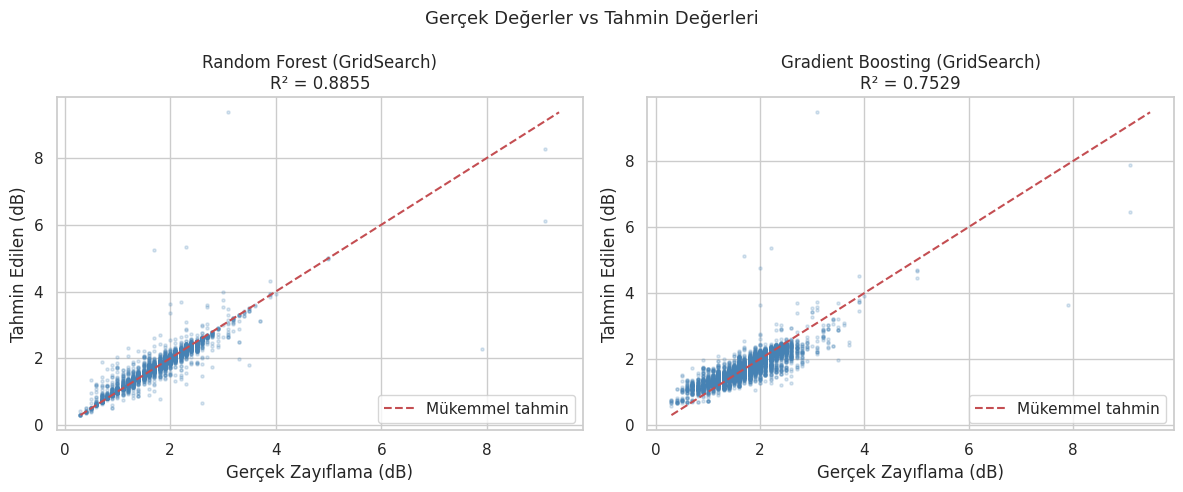

In [26]:
# En iyi 2 modeli görselleştirelim: GridSearch RF ve GridSearch GBM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Gerçek Değerler vs Tahmin Değerleri", fontsize=13)

for ax, (isim, grid) in zip(axes, [("Random Forest", rf_grid), ("Gradient Boosting", gbm_grid)]):
    tahmin = grid.predict(X_test)

    # Scatter: her nokta bir test verisi
    ax.scatter(y_test, tahmin, alpha=0.2, s=5, color="steelblue")

    # Mükemmel tahmin çizgisi: gerçek = tahmin
    min_val = min(y_test.min(), tahmin.min())
    max_val = max(y_test.max(), tahmin.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Mükemmel tahmin")

    r2 = r2_score(y_test, tahmin)
    ax.set_xlabel("Gerçek Zayıflama (dB)")
    ax.set_ylabel("Tahmin Edilen (dB)")
    ax.set_title(f"{isim} (GridSearch)\nR² = {r2:.4f}")
    ax.legend()

plt.tight_layout()
plt.show()


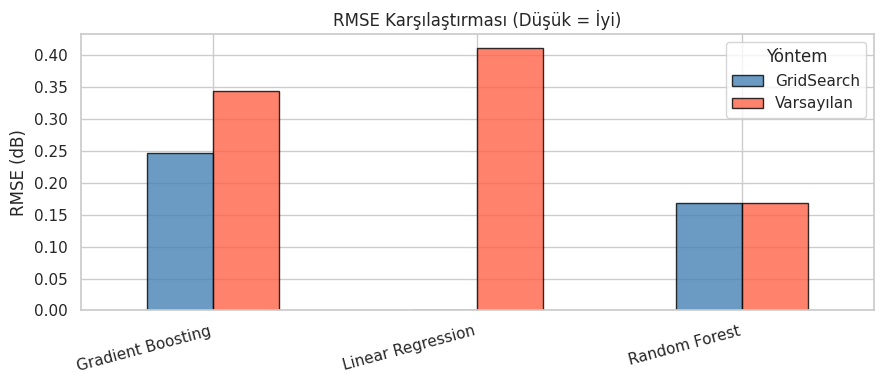


Not: RMSE ne kadar düşükse model o kadar başarılı demektir.


In [27]:
# ── RMSE Karşılaştırma Bar Grafiği ────────────────────────────────────────────
ozet = df_karsilastirma.pivot(index="Model", columns="Yöntem", values="RMSE")

ozet.plot(kind="bar", figsize=(9, 4), color=["steelblue", "tomato"],
          edgecolor="black", alpha=0.8)

plt.title("RMSE Karşılaştırması (Düşük = İyi)")
plt.ylabel("RMSE (dB)")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Yöntem")
plt.tight_layout()
plt.show()

print("\nNot: RMSE ne kadar düşükse model o kadar başarılı demektir.")


## 13. Özet — Öğrendiklerimiz

| Konu | Ne Öğrendik? |
|------|-------------|
| **Veri okuma** | `pd.read_excel()`, `.head()`, `.info()`, `.describe()` |
| **Eksik veriler** | `.isna()`, `.fillna()`, `SimpleImputer` |
| **Normalizasyon** | `MinMaxScaler` (0-1), `StandardScaler` (z-score) |
| **One-Hot Encoding** | `pd.get_dummies()` — metni 0/1 sütunlarına çevirir |
| **Train/Test Split** | `train_test_split()` — %80 eğitim, %20 test |
| **Model eğitimi** | `.fit()` eğit, `.predict()` tahmin yap |
| **Metrikler** | MSE, RMSE (dB cinsinden hata), R² (1 = mükemmel) |
| **GridSearchCV** | Otomatik hiperparametre arama, `cv=5` cross-validation |

### Hangi model en iyiydi?
Genellikle **Gradient Boosting (GridSearch)** en yüksek R² değerini verir —  
ama bu veri setine ve probleme göre değişebilir.

---
*Bu not defteri bir başlangıç rehberidir. Bir sonraki adım: feature engineering, regularization, ve model yorumlanabilirliği (SHAP değerleri).*
